# FFT of the ROI-averaged velocity spectrum

Interactive companion to `batch_VelocityFFT.ipynb` (velocity analogue of
[`fft_KineticEnergy.ipynb`](fft_KineticEnergy.ipynb)).

It reads a per-run `VelocityFFT.npz` (produced by `batch_VelocityFFT.ipynb`),
which already holds the **ROI-averaged single-sided amplitude spectra** of the
two velocity components — `amp_u`, `amp_v` and `amp_total = amp_u + amp_v` —
versus frequency `f`, computed with `np.fft.rfft` (mean removed, Hann window,
amplitude-corrected) and the PIV **field** sampling frequency `fps = cam_fps/2`.

Because the FFT is precomputed by the batch, this notebook only **loads and
plots** it (there is no time series stored and nothing is re-transformed). It
draws two panels:

1. the component spectra `|FFT(U)|` and `|FFT(V)|`;
2. the total amplitude spectrum `|FFT(U)| + |FFT(V)|`.

If the libration frequency can be parsed from the run name, dashed guides are
drawn at `flib` and `2*flib` (the interior velocity responds mainly at `flib`).

## 1. Imports

In [21]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

NPZ_NAME = "VelocityFFT.npz"
FLIB_DIVISOR = 1000.0   # folder token 'flib0400' -> 0.400 Hz (matches batch)
FROT_DIVISOR = 100.0    # folder token 'frot050'  -> 0.50  Hz (matches batch)

## 2. Configuration

Edit these, then run the cells below. `PATH` may be the `.npz` file itself or a
run folder (its `PostProcessing/VelocityFFT.npz` is used).

In [22]:
# --- edit me -------------------------------------------------------------
PATH   = ("/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/"
          "TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/"
          "frot050_flib1500_dphi8deg_SS1/PostProcessing")   # run folder or .npz
LOGY   = True        # logarithmic amplitude axis (False -> linear)
FMAX   = None        # upper frequency limit for the plot (Hz); None -> Nyquist
SAVE   = True       # also write a PNG next to the .npz
OUTPUT = None        # PNG path; None -> Velocity_FFT.png beside the .npz
OVERWRITE_POL = False  # (over)write Velocity_polarization_estimators.png next to
                       #  the .npz even if it exists (False -> keep existing)
# -------------------------------------------------------------------------

## 3. Helper functions

In [ ]:
def resolve_npz(path):
    """Accept the .npz path directly or a run folder containing it."""
    if os.path.isdir(path):
        cand = os.path.join(path, "PostProcessing", NPZ_NAME)
        if os.path.isfile(cand):
            return cand
        cand = os.path.join(path, NPZ_NAME)
        if os.path.isfile(cand):
            return cand
        raise FileNotFoundError("No %s under %s" % (NPZ_NAME, path))
    if os.path.isfile(path):
        return path
    raise FileNotFoundError(path)


def parse_flib(run_name):
    """Libration frequency (Hz) from a run name, or None."""
    m = re.search(r"flib(\d+)", str(run_name))
    return float(m.group(1)) / FLIB_DIVISOR if m else None


def peak_freq(f, amp):
    """Frequency and amplitude of the spectrum maximum, ignoring the DC bin."""
    if f.size < 2 or np.all(np.isnan(amp)):
        return np.nan, np.nan
    k = 1 + int(np.nanargmax(amp[1:]))
    return float(f[k]), float(amp[k])


def parse_frot(run_name):
    """Rotation frequency (Hz) from a run name, or None."""
    m = re.search(r"frot(\d+)", str(run_name))
    return float(m.group(1)) / FROT_DIVISOR if m else None


def compute_polarization(f, powerU, powerV, frot):
    """Polarization curve for one run (matches batch_VelocityFFT).

    Returns (f_pol, pol_IW, pol_data):
      f_pol    : 0.01..1 Hz, 100 points
      pol_IW   : 2*((2*frot/f_pol)**2 - 1), the inertial-wave prediction
                 (NaN if frot is unknown)
      pol_data : (powerV/powerU)**2 on the FFT frequency grid f
                 (NaN where powerU <= 0)
    """
    f_pol = np.linspace(0.01, 1.0, 100)
    if frot:
        pol_IW = 2.0 * ((2.0 * frot / f_pol) ** 2 - 1.0)
    else:
        pol_IW = np.full_like(f_pol, np.nan)
    pu = np.asarray(powerU, dtype=float)
    pv = np.asarray(powerV, dtype=float)
    pol_data = np.full_like(pu, np.nan)
    good = pu > 0
    pol_data[good] = (pv[good] / pu[good]) ** 2
    return f_pol, pol_IW, pol_data

## 4. Load the spectrum

In [24]:
npz_path = resolve_npz(PATH)
print("Reading %s" % npz_path)

data = np.load(npz_path, allow_pickle=True)
f = np.asarray(data["f"], dtype=float)
amp_u = np.asarray(data["amp_u"], dtype=float)
amp_v = np.asarray(data["amp_v"], dtype=float)
amp_total = np.asarray(data["amp_total"], dtype=float)
powerU = np.asarray(data["powerU"], dtype=float) if "powerU" in data.files else None
powerV = np.asarray(data["powerV"], dtype=float) if "powerV" in data.files else None
fps = float(data["fps"]) if "fps" in data.files else 1.0
run = str(data["run"]) if "run" in data.files else os.path.basename(
    os.path.dirname(npz_path))
window = str(data["window"]) if "window" in data.files else "?"
npoints = int(data["npoints"]) if "npoints" in data.files else -1
nframes = int(data["nframes"]) if "nframes" in data.files else f.size

flib = parse_flib(run)
frot = parse_frot(run)
print("run     = %s" % run)
print("fps     = %g Hz   nframes = %d   Nyquist = %g Hz" % (fps, nframes, f[-1]))
print("df      = %.4g Hz   ROI points averaged = %d   window = %s"
      % (f[1] - f[0] if f.size > 1 else np.nan, npoints, window))
print("flib    = %s" % ("%g Hz" % flib if flib else "unknown"))

Reading /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot050_flib1500_dphi8deg_SS1/PostProcessing/VelocityFFT.npz
run     = frot050_flib1500_dphi8deg_SS1
fps     = 40 Hz   nframes = 1500   Nyquist = 20 Hz
df      = 0.02667 Hz   ROI points averaged = 5607   window = hann
flib    = 1.5 Hz


## 5. Peak frequencies

In [25]:
for label, amp in (("U", amp_u), ("V", amp_v), ("total", amp_total)):
    fp, ap = peak_freq(f, amp)
    print("peak |FFT(%-5s)| at %.4f Hz   (amplitude = %.3e m/s)" % (label, fp, ap))
if flib:
    print("  reference: flib = %.4f Hz,  2*flib = %.4f Hz" % (flib, 2 * flib))

peak |FFT(U    )| at 0.0267 Hz   (amplitude = 1.784e-03 m/s)
peak |FFT(V    )| at 0.0533 Hz   (amplitude = 1.081e-03 m/s)
peak |FFT(total)| at 0.0267 Hz   (amplitude = 2.781e-03 m/s)
  reference: flib = 1.5000 Hz,  2*flib = 3.0000 Hz


## 6. Plot

Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot050_flib1500_dphi8deg_SS1/PostProcessing/Velocity_FFT.png


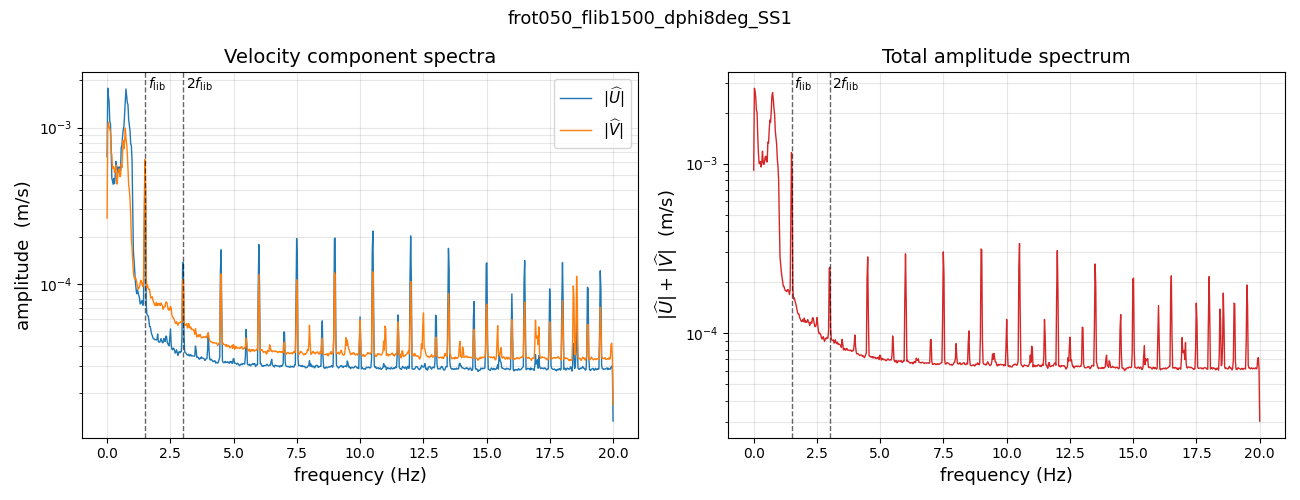

In [26]:
fmax = FMAX if FMAX else f[-1]
sel = f <= fmax


def add_guides(ax):
    if not flib:
        return
    for fq, lbl in ((flib, r"$f_{\mathrm{lib}}$"),
                    (2 * flib, r"$2f_{\mathrm{lib}}$")):
        if fq <= fmax:
            ax.axvline(fq, color="k", ls="--", lw=1, alpha=0.6)
            ax.annotate(lbl, xy=(fq, 1), xycoords=("data", "axes fraction"),
                        xytext=(2, -12), textcoords="offset points", fontsize=10)


plot = (lambda ax, *a, **k: ax.semilogy(*a, **k)) if LOGY else \
       (lambda ax, *a, **k: ax.plot(*a, **k))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: component amplitude spectra
plot(axes[0], f[sel], amp_u[sel], color="C0", lw=1, label=r"$|\widehat{U}|$")
plot(axes[0], f[sel], amp_v[sel], color="C1", lw=1, label=r"$|\widehat{V}|$")
axes[0].set_xlabel("frequency (Hz)", fontsize=13)
axes[0].set_ylabel(r"amplitude  (m/s)", fontsize=13)
axes[0].set_title("Velocity component spectra", fontsize=14)
axes[0].grid(True, alpha=0.3, which="both")
axes[0].legend(fontsize=11)
add_guides(axes[0])

# Panel 2: total amplitude spectrum
plot(axes[1], f[sel], amp_total[sel], color="C3", lw=1)
axes[1].set_xlabel("frequency (Hz)", fontsize=13)
axes[1].set_ylabel(r"$|\widehat{U}| + |\widehat{V}|$  (m/s)", fontsize=13)
axes[1].set_title("Total amplitude spectrum", fontsize=14)
axes[1].grid(True, alpha=0.3, which="both")
add_guides(axes[1])

fig.suptitle(run, fontsize=13)
fig.tight_layout()

if SAVE:
    output = OUTPUT or os.path.join(os.path.dirname(npz_path), "Velocity_FFT.png")
    fig.savefig(output, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % output)

plt.show()

## 7. Polarization estimators

Same figure as `batch_VelocityFFT`: overlays the inertial-wave relation
`2*((2*frot/f)**2 - 1)` with the measured ratios `powerV_mean/powerU_mean`,
`mean(powerV/powerU)` and `fftV2_mean/fftU2_mean`, all read from the `.npz`
(they cannot be recomputed here - the raw U/V time series are not stored).
Log y-axis, x limited to 0.01..1 Hz. Set `OVERWRITE_POL = True` to overwrite
`Velocity_polarization_estimators.png` next to the `.npz`.

polarization: recomputed from powerU/powerV
Polarization figure already exists (set OVERWRITE_POL=True to overwrite):
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot050_flib1500_dphi8deg_SS1/PostProcessing/Velocity_polarization.png


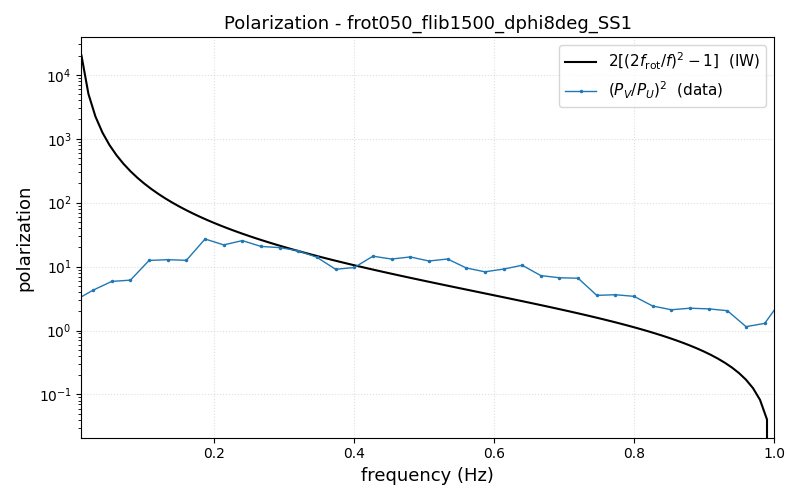

In [27]:
# Combined polarization estimators - identical to batch_VelocityFFT's figure.
# All arrays are read from the .npz (the raw U/V time series are not stored
# here, so nothing can be recomputed).
_need = ("powerVpowerU_Ratio", "powerRatio", "fftRatioV2U2")
if all(k in data.files for k in _need):
    m = f > 0
    figp, axp = plt.subplots(figsize=(9, 6))
    if frot:
        theory = 2.0 * ((2.0 * frot / f[m]) ** 2 - 1.0)
        axp.plot(f[m], theory, "k-", lw=2.2,
                 label=r"$2[(2f_{\mathrm{rot}}/f)^2-1]$  (IW)")
    axp.plot(f[m], np.asarray(data["powerVpowerU_Ratio"], dtype=float)[m],
             lw=1.0, label=r"$\overline{P_V}/\overline{P_U}$")
    axp.plot(f[m], np.asarray(data["powerRatio"], dtype=float)[m],
             lw=1.0, label=r"$\overline{P_V/P_U}$")
    axp.plot(f[m], np.asarray(data["fftRatioV2U2"], dtype=float)[m],
             lw=1.0,
             label=r"$\overline{|\mathrm{FFT}(V^2)|}/\overline{|\mathrm{FFT}(U^2)|}$")
    axp.set_yscale("log")
    axp.set_xlim(0.01, 1.0)
    axp.set_xlabel("frequency (Hz)", fontsize=13)
    axp.set_ylabel("polarization / ratio", fontsize=13)
    axp.set_title("Polarization estimators - %s" % run, fontsize=13)
    axp.grid(True, which="both", ls=":", alpha=0.4)
    axp.legend(fontsize=9)
    figp.tight_layout()

    pol_png = os.path.join(os.path.dirname(npz_path),
                           "Velocity_polarization_estimators.png")
    if OVERWRITE_POL or not os.path.isfile(pol_png):
        figp.savefig(pol_png, dpi=200, bbox_inches="tight")
        print("Polarization figure written to:\n  %s" % pol_png)
    else:
        print("Polarization figure already exists (set OVERWRITE_POL=True to "
              "overwrite):\n  %s" % pol_png)
    plt.show()
else:
    print("polarization estimators not in this .npz - reprocess with "
          "batch_VelocityFFT to add them")